# Обучение Model B (CNN + Channel Attention)
В этом ноутбуке мы обучим нашу архитектуру с механизмом внимания по отведениям (Leads). 
Это нужно, чтобы сравнить нашу модель с обычным бейзлайном и доказать, что взвешивание каналов дает прирост метрик.

In [1]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from src.models.model_b_attention import ModelBAttention
from src.data import get_dataloaders, set_seed
from src.eval import PTBXLEvaluator

set_seed(42)

Global seed set: 42


### 1. Загрузка данных (DataLoaders)
В датасете 12 каналов, частота 100Гц. 
Мы загружаем нашу `npz` выборку, разделенную на Train, Val и Test.

In [2]:
from src.data import get_class_weights_from_dataloader

data_path = "../data_preprocessed/ptbxl_sota_100hz_diagnostic_superclass.npz"
batch_size = 128

train_loader, val_loader, test_loader = get_dataloaders(
    data_path=data_path,
    batch_size=batch_size,
    num_workers=0,
    use_weighted_sampler=False
)

classes = train_loader.dataset.class_names

pos_weight = get_class_weights_from_dataloader(train_loader)

print(f"Готово! Классы: {classes}")
print(f"Кол-во батчей в Train: {len(train_loader)}")

Global seed set: 42
Loaded train split: 17418 samples
   Signal shape: (12, 1000)
   Classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
   Augmentation: ON
   Label distribution:
     NORM: 7596 (43.6%)
     MI: 4379 (25.1%)
     STTC: 4087 (23.5%)
     CD: 3907 (22.4%)
     HYP: 2119 (12.2%)
Loaded val split: 2183 samples
   Signal shape: (12, 1000)
   Classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
   Augmentation: OFF
   Label distribution:
     NORM: 955 (43.7%)
     MI: 540 (24.7%)
     STTC: 515 (23.6%)
     CD: 495 (22.7%)
     HYP: 268 (12.3%)
Loaded test split: 2198 samples
   Signal shape: (12, 1000)
   Classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
   Augmentation: OFF
   Label distribution:
     NORM: 963 (43.8%)
     MI: 550 (25.0%)
     STTC: 506 (23.0%)
     CD: 496 (22.6%)
     HYP: 262 (11.9%)

DataLoaders ready (seed=42, reproducible):
   Train batches: 136
   Val batches: 18
   Test batches: 18
Готово! Классы: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Кол-во батчей в Train: 136


### 2. Инициализация вашей Model B
Достаем модель из `src.models.model_b_attention`.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu"
))
print(f"Используем устройство: {device}")

model = ModelBAttention().to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

evaluator = PTBXLEvaluator(class_names=classes)

Используем устройство: mps


### 3. Цикл обучения (Training Loop)
Здесь мы пропишем простой train loop на 5-10 эпох чисто для проверки, либо вы можете поставить `EPOCHS=50`.

In [4]:
EPOCHS = 50
history = {
    'train_loss': [], 
    'val_loss': [], 
    'val_auroc': [],
    'val_auprc': [],
    'val_f1': []
}
best_val_auc = 0.0

import time

for epoch in range(EPOCHS):
    start_time = time.time()
    
    print(f"Пошла Эпоха {epoch+1}/{EPOCHS}... ", end="")
    
    model.train()
    train_loss = 0.0
    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)  
        loss = criterion(logits, y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        optimizer.step()
        
        train_loss += loss.item()
        
    train_loss /= len(train_loader)
    
    scheduler.step()
    
    model.eval()
    val_loss = 0.0
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            all_targets.append(y.cpu())
            all_probs.append(probs.cpu())
            
    val_loss /= len(val_loader)
    
    targets = torch.cat(all_targets).numpy()
    probs = torch.cat(all_probs).numpy()
    
    val_metrics = evaluator.evaluate(targets, probs)
    val_auroc = val_metrics['macro_auc']
    val_auprc = val_metrics['macro_auprc']
    val_f1    = val_metrics['f1_macro']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auroc'].append(val_auroc)
    history['val_auprc'].append(val_auprc)
    history['val_f1'].append(val_f1)
    
    if val_auroc > best_val_auc:
        best_val_auc = val_auroc
        if not os.path.exists('../results/model_b_attention'):
            os.makedirs('../results/model_b_attention')
        torch.save(model.state_dict(), '../results/model_b_attention/best_model_b_final.pth')
        saved_msg = "НОВЫЙ РЕКОРД! Сохранен."
    else:
        saved_msg = ""
        
    epoch_time = time.time() - start_time
    print(f"Готово! ({epoch_time:.0f} сек)")
    print(f"   loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | AUROC: {val_auroc:.4f} | AUPRC: {val_auprc:.4f} | F1: {val_f1:.4f} {saved_msg}")
    print("-" * 60)

print("Обучение всех 50 эпох завершено!")

Пошла Эпоха 1/50... Готово! (393 сек)
   loss: 0.7594 | val_loss: 0.7164 | AUROC: 0.8706 | AUPRC: 0.6917 | F1: 0.6463 НОВЫЙ РЕКОРД! Сохранен.
------------------------------------------------------------
Пошла Эпоха 2/50... Готово! (422 сек)
   loss: 0.6610 | val_loss: 0.8500 | AUROC: 0.8809 | AUPRC: 0.7137 | F1: 0.5692 НОВЫЙ РЕКОРД! Сохранен.
------------------------------------------------------------
Пошла Эпоха 3/50... Готово! (428 сек)
   loss: 0.6253 | val_loss: 0.6860 | AUROC: 0.8883 | AUPRC: 0.7340 | F1: 0.6519 НОВЫЙ РЕКОРД! Сохранен.
------------------------------------------------------------
Пошла Эпоха 4/50... Готово! (473 сек)
   loss: 0.6027 | val_loss: 0.6403 | AUROC: 0.9004 | AUPRC: 0.7490 | F1: 0.6816 НОВЫЙ РЕКОРД! Сохранен.
------------------------------------------------------------
Пошла Эпоха 5/50... Готово! (431 сек)
   loss: 0.5897 | val_loss: 0.7263 | AUROC: 0.8978 | AUPRC: 0.7469 | F1: 0.6814 
------------------------------------------------------------
Пошла Эп

### 4. Графики обучения
Построим Loss и AUROC чтобы показать хорошую сходимость модели Attention.

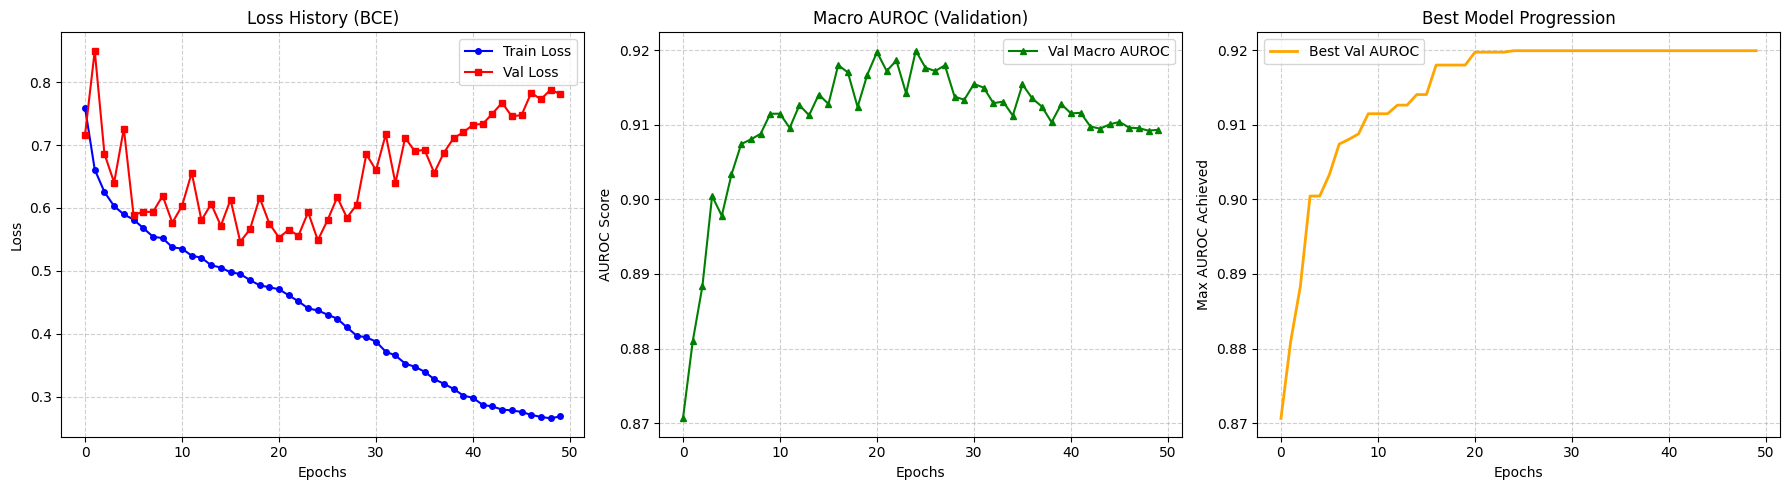

In [5]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o', markersize=4)
plt.plot(history['val_loss'], label='Val Loss', color='red', marker='s', markersize=4)
plt.title('Loss History (BCE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 2)
plt.plot(history['val_auroc'], label='Val Macro AUROC', color='green', marker='^', markersize=4)
plt.title('Macro AUROC (Validation)')
plt.xlabel('Epochs')
plt.ylabel('AUROC Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

best_auroc_progression = [max(history['val_auroc'][:i+1]) for i in range(len(history['val_auroc']))]
plt.subplot(1, 3, 3)
plt.plot(best_auroc_progression, label='Best Val AUROC', color='orange', linewidth=2, linestyle='-')
plt.title('Best Model Progression')
plt.xlabel('Epochs')
plt.ylabel('Max AUROC Achieved')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 5. Финальная оценка (Оценка на Test Set)
Теперь, когда наша модель обучилась, нам нужно загрузить **самый лучший чекпоинт** (который дал наибольший AUROC на валидации) и прогнать его на отложенной тестовой выборке (`test_loader`), которую модель никогда не видела. 

Это и будут ваши финальные цифры для таблицы в дипломе!

In [6]:
model.load_state_dict(torch.load('../results/model_b_attention/best_model_b_final.pth', map_location=device))
model.eval()

all_test_targets = []
all_test_probs = []

print("Оцениваем на тестовой выборке (Test Set)...")
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits)
        
        all_test_targets.append(y.cpu())
        all_test_probs.append(probs.cpu())

test_targets = torch.cat(all_test_targets).numpy()
test_probs = torch.cat(all_test_probs).numpy()

test_metrics = evaluator.evaluate(test_targets, test_probs)

print("\n" + "="*70)
print(f"{'TEST — MODEL_B_ATTENTION':^70}")
print("="*70)

print("\n Core Metrics (Official PTB-XL)")
print(f"   Macro AUROC:  {test_metrics['macro_auc']:.4f} (5/5 classes)")
print(f"   Micro AUROC:  {test_metrics.get('micro_auc', 0.0):.4f}")
print(f"   Macro AUPRC:  {test_metrics['macro_auprc']:.4f}")
print(f"   Fmax:         {test_metrics.get('fmax', 0.0):.4f} (optimal threshold: {test_metrics.get('optimal_threshold', 0.5):.3f})")
print(f"   F1 Macro:     {test_metrics.get('f1_macro', 0.0):.4f} (@ threshold={test_metrics.get('threshold_used', 0.50):.2f})")
print(f"   F1 Micro:     {test_metrics.get('f1_micro', 0.0):.4f}")

print("\n Medical Metrics")
print(f"   Sensitivity (Recall): {test_metrics.get('sensitivity', 0.0):.4f}")
print(f"   Specificity:          {test_metrics.get('specificity', 0.0):.4f}")

print("\n Per-Class Metrics")
print(f"{'Class':<10} {'AUROC':<8} {'AUPRC':<8} {'F1':<8} {'Sens.':<8} {'Spec.':<8} {'Opt.Thr':<8} {'Support':<8}")
print("-" * 74)

for cls_name in classes:
    m = test_metrics['per_class'][cls_name]
    thr = test_metrics['per_class_thresholds'].get(cls_name, 0.5)
    
    auc_val = m['auroc'] if m['auroc'] is not None else 0.0
    auprc_val = m['auprc'] if m['auprc'] is not None else 0.0
    f1_val = m['f1'] if m['f1'] is not None else 0.0
    sens_val = m['sensitivity'] if m['sensitivity'] is not None else 0.0
    spec_val = m['specificity'] if m['specificity'] is not None else 0.0
    support = m['support'] if m['support'] is not None else 0
    opt_thr = thr if thr is not None else 0.5
    
    print(f"{cls_name:<10} {auc_val:.4f}   {auprc_val:.4f}   {f1_val:.4f}   {sens_val:.4f}   {spec_val:.4f}   {opt_thr:.3f}    {support:<8}")

print("="*70)

Оцениваем на тестовой выборке (Test Set)...

                       TEST — MODEL_B_ATTENTION                       

 Core Metrics (Official PTB-XL)
   Macro AUROC:  0.9138 (5/5 classes)
   Micro AUROC:  0.9161
   Macro AUPRC:  0.7913
   Fmax:         0.7317 (optimal threshold: 0.674)
   F1 Macro:     0.6872 (@ threshold=0.50)
   F1 Micro:     0.7128

 Medical Metrics
   Sensitivity (Recall): 0.8422
   Specificity:          0.8250

 Per-Class Metrics
Class      AUROC    AUPRC    F1       Sens.    Spec.    Opt.Thr  Support 
--------------------------------------------------------------------------
NORM       0.9414   0.9154   0.8501   0.8629   0.8696   0.333    963     
MI         0.9251   0.8221   0.7226   0.8855   0.8113   0.818    550     
STTC       0.9309   0.8202   0.7127   0.8874   0.8197   0.784    506     
CD         0.9194   0.8352   0.7364   0.7661   0.9083   0.593    496     
HYP        0.8520   0.5637   0.4141   0.8092   0.7159   0.842    262     
